<a href="https://colab.research.google.com/github/24hours68435790-cmd/PS1-Feiyu/blob/main/companion/notebooks/PS1_strategic_disclosure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# When the Model Becomes the Target
### Strategic Disclosure under AI-Assisted Valuation — PS1 computational artifact

**Feiyu Li** · `fl140` · COMSCI/ECON 206, Computational Microeconomics ·
Autumn 2026 Session 1 · Workshop Session G (Team 7) · Instructor: Prof. Luyao Zhang

---

**Research question.** When firms know the metrics an AI valuation model uses, under what
conditions can an evaluator that *remembers* a particular firm substitute for one that
*commits* to a fixed rule — and when does remembering instead punish the honest?

This notebook and the browser game at
[huggingface.co/spaces/24hours6964/strategic-disclosure-game](https://huggingface.co/spaces/24hours6964/strategic-disclosure-game)
answer the **same** question with the **same** model. They differ in scope only:

| | Browser Space | This notebook |
|---|---|---|
| purpose | teaching artifact, playable | evidence |
| draws | one seed, hand-played | 20,000 per cell |
| memory strength | fixed at λ = 1 | swept 0 → 2 |
| outcome noise | fixed 3-point ε | swept σ = 0 → 3 |
| window-dressing grid | {0, 1, 2} | {0, 0.25, …, 2} |

Section 3 of the paper calls the check below *meaningful* for one reason: the notebook
re-implements JavaScript's `mulberry32` PRNG in Python and must reproduce the deployed
page's logged prices **to the cent** before it is allowed to report anything new.

> ⚠️ **Evidence status.** Everything below is a simulated output of my own model.
> Nothing here is evidence about human behaviour, about any real AI system, or about
> any real firm. H1–H3 are hypotheses; the paper states exactly which margin each
> survives on.

## 0 · Setup

Fill in `REPO_URL` once with your own fork. The notebook loads the model from
`companion/src/` in the repository, so the code you run here is byte-identical to the
code a grader reads — not a second copy that could drift.

In [1]:
# >>> FILL IN: your own fork's URL (the PS1-Feiyu repo on your personal account) <<<
REPO_URL = "https://github.com/24hours68435790-cmd/PS1-Feiyu"

import os, subprocess, sys

# Works three ways: already inside the repo, already cloned, or a fresh Colab VM.
REPO_DIR = REPO_URL.rstrip("/").split("/")[-1].removesuffix(".git")
CANDIDATES = ["../src", "src", f"{REPO_DIR}/companion/src"]

def _found():
    return [c for c in CANDIDATES if os.path.exists(os.path.join(c, "strategic_disclosure.py"))]

if not _found():
    subprocess.run(["git", "clone", "--quiet", REPO_URL, REPO_DIR], check=True)
if not _found():
    raise SystemExit(
        f"Could not find companion/src in {REPO_URL}.\n"
        "Check that REPO_URL points at your own fork and that it has been pushed."
    )
SRC = _found()[0]
sys.path.insert(0, SRC)
print(f"model loaded from: {os.path.abspath(SRC)}")

import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt

import strategic_disclosure as sd
import run_experiments as rx

pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:7.3f}")
plt.rcParams.update({"figure.dpi": 120, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

print(f"python     {sys.version.split()[0]}")
print(f"numpy      {np.__version__}")
print(f"pandas     {pd.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"\nmodel constants: m_bar={sd.M_BAR}, lambda={sd.LAMBDA}, effort cost={sd.EFFORT_COST}")

model loaded from: /content/PS1-Feiyu/companion/src
python     3.13.15
numpy      2.1.3
pandas     2.2.3
matplotlib 3.10.0

model constants: m_bar=1.0, lambda=1.0, effort cost=0.5


## 1 · The notebook is the same model as the browser game

`Space` is a Python port of the deployed `index.html`, including JavaScript's
`mulberry32` closure and `Math.imul` (emulated as unsigned 32-bit arithmetic).

`verify_space_replication()` **asserts** — if any price, payoff or residual disagrees
with what the browser logged on 6 September 2026, this cell raises and the rest of the
notebook never runs. A silent disagreement is not possible.

In [2]:
assert sd.verify_space_replication()
assert sd.verify_vectorisation()
print("Python twin reproduces all four logged browser cases   [OK]")
print("vectorised expectation agrees with the scalar model    [OK]\n")

rows = []
for mode in ("committed", "revisable"):
    js_mode = "static" if mode == "committed" else "memory"
    for label, (a, m) in {
        "boundary (manipulator, m=2)": (0, 2),
        "typical  (honest,      m=0)": (1, 0),
    }.items():
        sp = sd.Space(seed=2026, mode=js_mode)
        for _ in range(2):
            r = sp.submit(a, m)
            rows.append({"case": label, "rule": mode, "round": r.round,
                         "theta": sp.theta, "k": sp.k, "v": r.v, "s": r.s,
                         "eps": r.eps, "price": r.p, "|p-v|": r.mispricing,
                         "payoff": r.payoff, "g": r.g})
display(pd.DataFrame(rows))

print("\nIntentionally invalid input (m = 7, above the grid ceiling of 2):")
try:
    sd.Space(seed=2026).submit(0, 7)
except ValueError as e:
    print("  rejected ->", e)

Python twin reproduces all four logged browser cases   [OK]
vectorised expectation agrees with the scalar model    [OK]



,case,rule,round,theta,k,v,s,eps,price,|p-v|,payoff,g
0,"boundary (manipulator, m=2)",committed,1,2,0.500,2,4,0.000,3.000,1.000,1.000,1.000
1,"boundary (manipulator, m=2)",committed,2,2,0.500,2,4,0.000,3.000,1.000,1.000,1.000
2,"typical (honest, m=0)",committed,1,2,0.500,3,3,0.000,2.000,1.000,1.500,-1.000
3,"typical (honest, m=0)",committed,2,2,0.500,3,3,0.000,2.000,1.000,1.500,-1.000
4,"boundary (manipulator, m=2)",revisable,1,2,0.500,2,4,0.000,3.000,1.000,1.000,1.000
5,"boundary (manipulator, m=2)",revisable,2,2,0.500,2,4,0.000,2.000,0.000,0.000,1.000
6,"typical (honest, m=0)",revisable,1,2,0.500,3,3,0.000,2.000,1.000,1.500,-1.000
7,"typical (honest, m=0)",revisable,2,2,0.500,3,3,0.000,3.000,0.000,2.500,-1.000



Intentionally invalid input (m = 7, above the grid ceiling of 2):
  rejected -> 7 is outside the valid range 0-2; the Space rejects the report, does not advance the round, and modifies no state.


### 1.1 · The flaw v1 reported about itself

v1 played four rounds on seed 2026 and noted, in its own Appendix A.3, that the
outcome noise ε drew 0.00 in **all six priced rounds** — so the channel where memory
could mistake an unlucky honest firm for a manipulator was entirely untested.

Both peer reviewers independently landed on this. Before fixing it, here is how big
an accident it was.

In [3]:
seeds = rx.seed_audit(500)
share = seeds["both_zero"].mean()
print(f"eps = 0.00 in BOTH priced rounds: {share:.1%} of 500 seeds")

sp = sd.Space(seed=2026)
e = [sp.submit(1, 0).eps for _ in range(2)]
print(f"seed 2026 (used in v1): eps = {e}  -> one of that {share:.1%}")
print("\nNot a bug. A one-in-eight corner that v1 then generalised from.")
print("Everything below uses 20,000 draws per cell instead.")

eps = 0.00 in BOTH priced rounds: 12.8% of 500 seeds
seed 2026 (used in v1): eps = [0.0, 0.0]  -> one of that 12.8%

Not a bug. A one-in-eight corner that v1 then generalised from.
Everything below uses 20,000 draws per cell instead.


## 2 · Committed vs revisable rules under outcome noise

*Reviewer 1: “The effect of noise should be tested more carefully… Test the model
under different levels of outcome noise.”*

Following Prof. Zhang's Week 2 note — *“compare fixed and revisable evaluator rules in
the same game; record deviation gains as well as disclosure accuracy”* — the two rules are:

- **COMMITTED** — the announced allowance $\bar m$ is the one followed, always.
  $p = \max(0,\; s - \bar m)$
- **REVISABLE** — $\bar m$ is still *announced*, but after round 1 the evaluator
  *follows* $\bar m + \lambda g_1$, where $g_1 = (s_1 - y_1) - \bar m$.

The wedge between announced and followed is the object Banchio, Skrzypacz and Yang
analyse for auctions; this transplants it to valuation.

**Deviation gain** = expected payoff of the best strategy − expected payoff of
reporting honestly at the same effort. Zero means the rule leaves a truthful firm
nothing to gain by inflating.

In [4]:
noise = rx.sweep_noise()
display(noise.pivot(index="sigma", columns="rule",
                    values=["honest_share", "mispricing", "welfare", "deviation_gain"]))

honest_share           mispricing             welfare           deviation_gain          
rule     committed revisable  committed revisable committed revisable      committed revisable
sigma                                                                                         
0.000        0.667     0.667      0.667     0.667     5.667     5.833          0.333     0.167
0.250        0.667     0.667      0.667     0.708     5.667     5.833          0.333     0.167
0.500        0.667     0.667      0.667     0.750     5.667     5.833          0.333     0.167
0.750        0.667     0.667      0.667     0.791     5.667     5.833          0.333     0.167
1.000        0.667     0.667      0.667     0.833     5.667     5.833          0.333     0.167
1.250        0.667     0.667      0.667     0.878     5.667     5.833          0.333     0.167
1.500        0.667     0.667      0.667     0.929     5.667     5.833          0.333     0.167
2.000        0.667     0.667      0.667     1.040     5.667     5.833          0.333     0.167
2.500        0.667     0.667      0.667     1.155     5.667     5.833          0.333     0.164
3.000        0.667     0.667      0.667     1.268     5.667     5.833          0.333     0.157

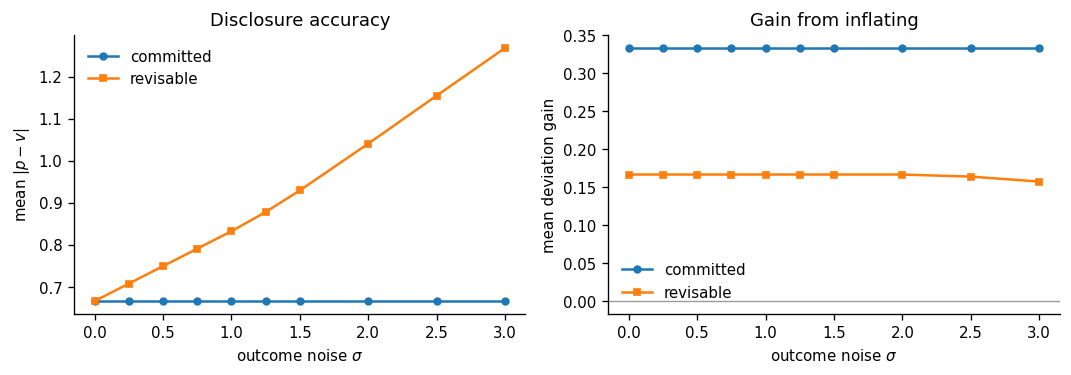

Read this as two separate answers, not one:
  accuracy  -> the revisable rule gets WORSE as noise rises
  deterrence-> the revisable rule roughly HALVES the gain from inflating,
               and that result is flat in sigma across [0, 3]


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
for rule, style in (("committed", "-o"), ("revisable", "-s")):
    d = noise[noise["rule"] == rule]
    ax[0].plot(d["sigma"], d["mispricing"], style, ms=4, label=rule)
    ax[1].plot(d["sigma"], d["deviation_gain"], style, ms=4, label=rule)
ax[0].set(xlabel=r"outcome noise $\sigma$", ylabel=r"mean $|p-v|$",
          title="Disclosure accuracy")
ax[1].set(xlabel=r"outcome noise $\sigma$", ylabel="mean deviation gain",
          title="Gain from inflating")
ax[1].axhline(0, color="0.6", lw=0.8)
for a in ax: a.legend(frameon=False)
fig.tight_layout(); plt.show()

print("Read this as two separate answers, not one:")
print("  accuracy  -> the revisable rule gets WORSE as noise rises")
print("  deterrence-> the revisable rule roughly HALVES the gain from inflating,")
print("               and that result is flat in sigma across [0, 3]")

## 3 · Can memory incorrectly punish an honest firm?

*Reviewer 1's question, verbatim.* The answer is **yes, and there is a threshold.**

For an honest firm $m = 0$, so $s = v$, $y = v + \varepsilon$, and
$g_1 = -\varepsilon - \bar m$. The revisable round-2 price is therefore

$$p = \max\bigl(0,\; v - \bar m + \lambda(\varepsilon + \bar m)\bigr),
\qquad\text{which at } \lambda = 1 \text{ is } \max(0,\, v + \varepsilon).$$

So the honest firm is under-priced whenever $\varepsilon < 0$ — half the time — but it
is priced *worse than under commitment* only when $|\varepsilon| > \bar m$. For
$\varepsilon \sim U(-\sigma, \sigma)$ that share is $(\sigma - \bar m)/\sigma$,
zero until $\sigma$ exceeds the announced allowance.

The cell below derives nothing; it *checks* that hand derivation against simulation.

In [6]:
fp = rx.sweep_false_punishment()
one = fp[fp["lambda"] == 1.0].copy()
one["analytic_worse_share"] = [max(0.0, (s - sd.M_BAR) / s) if s > 0 else 0.0
                               for s in one["sigma"]]
one["analytic_mae"] = one["sigma"] / 2.0
display(one[["sigma", "under_priced_share", "worse_than_committed_share",
             "analytic_worse_share", "mae_revisable", "analytic_mae", "mae_committed"]])

gap = (one["worse_than_committed_share"] - one["analytic_worse_share"]).abs().max()
print(f"max |simulation - analytic| on the mis-punishment share: {gap:.4f}")
print(f"\nThreshold 1  sigma* = m_bar = {sd.M_BAR}   -> any given honest firm starts")
print( "             being priced worse than under commitment")
print(f"Threshold 2  sigma** = 2*m_bar = {2*sd.M_BAR} -> the AVERAGE honest firm is")
print( "             priced worse (mean |p-v| crosses m_bar)")
print("\nSmall and young firms are exactly the ones with noisy outcomes, so this")
print("ratio -- noise over announced allowance -- is the disparate-impact quantity.")

,sigma,under_priced_share,worse_than_committed_share,analytic_worse_share,mae_revisable,analytic_mae,mae_committed
10,0.000,0.000,0.000,0.000,0.000,0.000,1.000
11,0.250,0.499,0.000,0.000,0.125,0.125,1.000
12,0.500,0.499,0.000,0.000,0.250,0.250,1.000
13,0.750,0.499,0.000,0.000,0.375,0.375,1.000
14,1.000,0.499,0.000,0.000,0.500,0.500,1.000
15,1.250,0.499,0.198,0.200,0.624,0.625,1.000
16,1.500,0.499,0.331,0.333,0.749,0.750,1.000
17,2.000,0.499,0.500,0.500,0.999,1.000,1.000
18,2.500,0.499,0.600,0.600,1.249,1.250,1.000
19,3.000,0.499,0.668,0.667,1.499,1.500,1.000


max |simulation - analytic| on the mis-punishment share: 0.0022

Threshold 1  sigma* = m_bar = 1.0   -> any given honest firm starts
             being priced worse than under commitment
Threshold 2  sigma** = 2*m_bar = 2.0 -> the AVERAGE honest firm is
             priced worse (mean |p-v| crosses m_bar)

Small and young firms are exactly the ones with noisy outcomes, so this
ratio -- noise over announced allowance -- is the disparate-impact quantity.


## 4 · Memory strength λ

*Reviewer 2: “can test more … and memory strength before drawing conclusion.”*

This one changed a conclusion of mine rather than confirming it. λ = 1 was hard-coded
in the v1 browser demo for no reason better than that it was round.

In [7]:
lam05 = rx.sweep_lambda(0.5)
lam15 = rx.sweep_lambda(1.5)
print("sigma = 0.5"); display(lam05)
print("sigma = 1.5"); display(lam15)

sigma = 0.5


,lambda,sigma,rule,honest_share,manipulation,mispricing,welfare,deviation_gain,max_deviation_gain
0,0.000,0.500,revisable,0.667,0.333,0.667,5.667,0.333,1.000
1,0.250,0.500,revisable,0.667,0.333,0.594,5.667,0.250,0.750
2,0.500,0.500,revisable,0.667,0.167,0.750,5.833,0.167,0.500
3,0.750,0.500,revisable,0.667,0.167,0.716,5.833,0.167,0.500
4,1.000,0.500,revisable,0.667,0.167,0.750,5.833,0.167,0.500
5,1.250,0.500,revisable,0.667,0.167,0.828,5.833,0.167,0.500
6,1.500,0.500,revisable,0.667,0.167,0.928,5.833,0.167,0.500
7,1.750,0.500,revisable,0.667,0.167,1.042,5.833,0.167,0.500
8,2.000,0.500,revisable,0.667,0.167,1.164,5.833,0.167,0.500
9,NaN,0.500,committed,0.667,0.333,0.667,5.667,0.333,1.000


sigma = 1.5


,lambda,sigma,rule,honest_share,manipulation,mispricing,welfare,deviation_gain,max_deviation_gain
0,0.000,1.500,revisable,0.667,0.333,0.667,5.667,0.333,1.000
1,0.250,1.500,revisable,0.667,0.333,0.615,5.667,0.250,0.750
2,0.500,1.500,revisable,0.667,0.222,0.707,5.778,0.167,0.500
3,0.750,1.500,revisable,0.667,0.167,0.832,5.833,0.167,0.500
4,1.000,1.500,revisable,0.667,0.167,0.929,5.833,0.167,0.500
5,1.250,1.500,revisable,0.667,0.167,1.041,5.833,0.167,0.500
6,1.500,1.500,revisable,0.667,0.167,1.160,5.833,0.167,0.500
7,1.750,1.500,revisable,0.667,0.167,1.284,5.833,0.167,0.500
8,2.000,1.500,revisable,0.667,0.167,1.410,5.833,0.167,0.500
9,NaN,1.500,committed,0.667,0.333,0.667,5.667,0.333,1.000


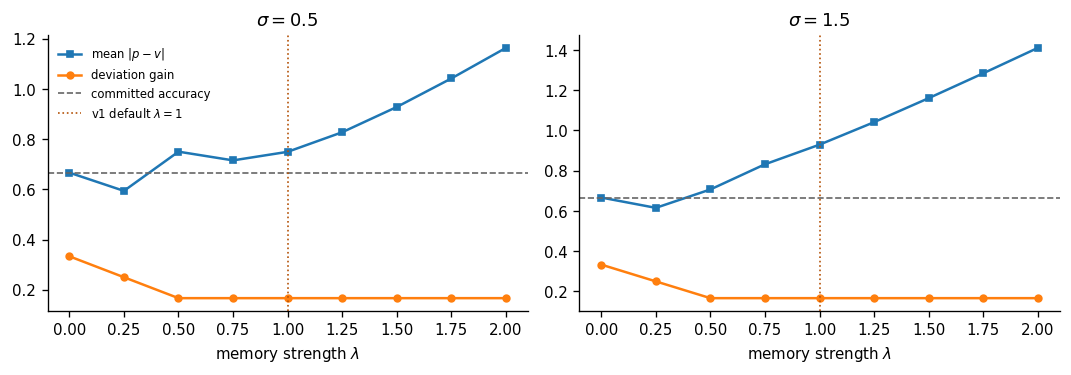

Deterrence SATURATES by lambda = 0.5 and is flat to lambda = 2.
Accuracy is best at lambda = 0.25 and degrades monotonically after.
=> the lambda = 1 in my v1 demo is on the wrong side of both.

This is also the evidence that discriminates the two behavioural stories
in Section 4 of the paper: a manipulation-COST story predicts saturation
once the anticipated punishment exceeds the gain; a BOUNDED-REASONING
story predicts continued response to a more visible punishment.
What we see is saturation.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
for a, d, s in ((ax[0], lam05, 0.5), (ax[1], lam15, 1.5)):
    r = d[d["rule"] == "revisable"]
    a.plot(r["lambda"], r["mispricing"], "-s", ms=4, label=r"mean $|p-v|$")
    a.plot(r["lambda"], r["deviation_gain"], "-o", ms=4, label="deviation gain")
    base = d[d["rule"] == "committed"]["mispricing"].iloc[0]
    a.axhline(base, color="0.4", ls="--", lw=1, label="committed accuracy")
    a.axvline(1.0, color="#b45309", lw=1, ls=":", label=r"v1 default $\lambda=1$")
    a.set(xlabel=r"memory strength $\lambda$", title=rf"$\sigma = {s}$")
ax[0].legend(frameon=False, fontsize=7)
fig.tight_layout(); plt.show()

print("Deterrence SATURATES by lambda = 0.5 and is flat to lambda = 2.")
print("Accuracy is best at lambda = 0.25 and degrades monotonically after.")
print("=> the lambda = 1 in my v1 demo is on the wrong side of both.")
print()
print("This is also the evidence that discriminates the two behavioural stories")
print("in Section 4 of the paper: a manipulation-COST story predicts saturation")
print("once the anticipated punishment exceeds the gain; a BOUNDED-REASONING")
print("story predicts continued response to a more visible punishment.")
print("What we see is saturation.")

## 5 · Grid sensitivity — the check v1 promised and did not run

v1 wrote: *“Grid sensitivity between the coarse browser grid and the research grid
will be reported rather than hidden.”* It was never run. Here it is, and it matters:
the *honest share* is an artefact of the grid, while the magnitude measures are not.

In [9]:
grids = rx.sweep_grid_sensitivity(sigma=0.5)
display(grids)

print(f"{'grid':10s} {'honest share':>26s} {'mean |p-v|':>22s} {'deviation gain':>24s}")
for g in ("browser", "research"):
    d = grids[grids["grid"] == g].set_index("rule")
    hs = f'{d.loc["committed","honest_share"]:.3f} -> {d.loc["revisable","honest_share"]:.3f}'
    mp = f'{d.loc["committed","mispricing"]:.3f} -> {d.loc["revisable","mispricing"]:.3f}'
    dg = f'{d.loc["committed","deviation_gain"]:.3f} -> {d.loc["revisable","deviation_gain"]:.3f}'
    print(f"{g:10s} {hs:>26s} {mp:>22s} {dg:>24s}")
print()
print("Deviation gain: halved on BOTH grids (exactly 2.00x). Robust.")
print("Welfare:        higher under revisable on BOTH grids. Robust.")
print("Accuracy:       worse under revisable on BOTH grids -- its round-2 price")
print("                carries the noise, while committed just deducts a constant.")
print("Honest share:   0.667 on the coarse grid, 0.000 on the fine one, under BOTH")
print("                rules. THIS is the grid artefact: a finer m grid always leaves")
print("                a profitable small inflation, so nobody is fully honest.")
print()
print("=> H3 must be stated on deviation gain and welfare (magnitudes that survive")
print("   the grid change), not on a binary honest/dishonest split, which does not.")

,grid,n_types,n_wd,rule,sigma,honest_share,manipulation,mispricing,welfare,deviation_gain,max_deviation_gain
0,browser,9,3,committed,0.500,0.667,0.333,0.667,5.667,0.333,1.000
1,browser,9,3,revisable,0.500,0.667,0.167,0.750,5.833,0.167,0.500
2,research,21,9,committed,0.500,0.000,0.714,0.571,5.263,0.692,2.000
3,research,21,9,revisable,0.500,0.000,0.357,0.869,5.632,0.346,1.000


grid                     honest share             mean |p-v|           deviation gain
browser                0.667 -> 0.667         0.667 -> 0.750           0.333 -> 0.167
research               0.000 -> 0.000         0.571 -> 0.869           0.692 -> 0.346

Deviation gain: halved on BOTH grids (exactly 2.00x). Robust.
Welfare:        higher under revisable on BOTH grids. Robust.
Accuracy:       worse under revisable on BOTH grids -- its round-2 price
                carries the noise, while committed just deducts a constant.
Honest share:   0.667 on the coarse grid, 0.000 on the fine one, under BOTH
                rules. THIS is the grid artefact: a finer m grid always leaves
                a profitable small inflation, so nobody is fully honest.

=> H3 must be stated on deviation gain and welfare (magnitudes that survive
   the grid change), not on a binary honest/dishonest split, which does not.


### 5.1 · Which firm types actually inflate

Averages hide the mechanism. Per type, at σ = 0.5 and λ = 1:

In [10]:
detail = rx.per_type_detail(sigma=0.5)
display(detail)

cheap = detail[(detail["k"] == 0.5)]
print("Only the cheap-to-manipulate type (k = 0.5) inflates at all -- H1.")
print()
print("Under the REVISABLE rule that type sets m1 = 0 but still m2 = 1:")
print("memory disciplines every round that has a SUCCESSOR, and no more.")
print("A two-period game has exactly one such round, so H3 is bounded by the horizon.")

,theta,k,rule,a1,m1,a2,m2,payoff,mispricing,welfare,deviation_gain
0,1,0.500,committed,1,1.000,1,1.000,2.000,0.000,3.000,1.000
1,1,0.500,revisable,1,0.000,1,1.000,2.497,0.998,3.500,0.500
2,1,1.000,committed,1,0.000,1,0.000,1.000,1.000,4.000,0.000
3,1,1.000,revisable,1,0.000,1,0.000,1.997,0.625,4.000,0.000
4,1,2.000,committed,1,0.000,1,0.000,1.000,1.000,4.000,0.000
5,1,2.000,revisable,1,0.000,1,0.000,1.997,0.625,4.000,0.000
6,2,0.500,committed,1,1.000,1,1.000,4.000,0.000,5.000,1.000
7,2,0.500,revisable,1,0.000,1,1.000,4.497,0.998,5.500,0.500
8,2,1.000,committed,1,0.000,1,0.000,3.000,1.000,6.000,0.000
9,2,1.000,revisable,1,0.000,1,0.000,3.997,0.625,6.000,0.000


Only the cheap-to-manipulate type (k = 0.5) inflates at all -- H1.

Under the REVISABLE rule that type sets m1 = 0 but still m2 = 1:
memory disciplines every round that has a SUCCESSOR, and no more.
A two-period game has exactly one such round, so H3 is bounded by the horizon.


## 6 · What this does and does not show

**Obtained** (simulated outputs of this model):

1. The revisable rule roughly **halves the deviation gain** — 0.692 → 0.346 on the
   research grid — at every noise level tested.
2. That deterrence **stops in the terminal round**: memory only disciplines rounds
   that have a successor.
3. The revisable rule **under-prices an honest firm in ~50% of noisy draws**, and is
   worse than commitment once σ > m̄, with share (σ − m̄)/σ.
4. Deterrence **saturates at λ ≈ 0.5** while accuracy peaks at λ ≈ 0.25 — λ = 1 is
   optimal for neither.
5. The coarse browser grid reports a **two-thirds honest share** that vanishes on a
   finer grid; the deviation-gain and welfare comparisons survive both grids.

**Not obtained, and not claimed:**

- No equilibrium fixed point. Best responses are computed against a *posted* rule,
  not solved as a perfect Bayesian equilibrium. The CFR computation in OpenSpiel that
  would replace this is the “Next study” row of Table 1.
- No behavioural evidence. The convex manipulation cost is a modelling assumption
  inherited from Fischbacher & Föllmi-Heusi as motivation, never estimated. Whether
  reporting officers pay a cost or simply reason boundedly is **not settled here** —
  the λ-saturation in §4 is *suggestive* evidence, and the discriminating test is a
  within-subject reporting experiment that has not been run.
- No horizon beyond two rounds, so memory and last-period unravelling are not
  separated.
- Nothing about any real firm, any real valuation model, or any real market.

**What would change my mind.** If λ-saturation disappeared on a finer λ grid, or if
elicited manipulation costs proved flat rather than convex, the deterrence result
would be an artefact of my functional form and H3 would have to be withdrawn.

---

**Reproduce everything from a shell instead:**

```bash
cd companion
pip install -r requirements.txt
python src/run_experiments.py           # ~4 s, deterministic, writes results/*.csv
python -m unittest discover -s tests    # 15 tests, each one a claim the paper makes
```

**AI-use disclosure** for this notebook is in Appendix A.1 of the paper.
Initial reasoning, the research design and H1–H3 are Human-Only; the Python port of
`mulberry32` and the sweep harness were written with AI assistance and then checked
against the browser log by hand.